# RNN


RNN(Recurrent Neural Network)은 **순차 데이터(Sequential Data)** 를 처리하기 위해 설계된 인공 신경망이다. RNN은 입력 데이터의 시간적 순서를 고려하여 정보를 처리하며, 특히 텍스트, 음성, 시계열 데이터 등에서 많이 사용된다.


- **특화**: 시퀀스 데이터 처리에 강점이 있음
- **기억 능력**: 이전 입력을 '기억'하며 처리
  - 네트워크는 입력 데이터를 요약하여 기억을 저장
  - 새로운 입력이 들어올 때마다 기억을 조금씩 수정
  - 모든 입력을 처리한 후, 남은 기억은 시퀀스를 전체적으로 요약하는 정보로 활용
- **반복적 처리**: 입력마다 기억을 갱신하며 순환적으로 진행 (사람이 단어를 기억하며 이해하는 방식과 유사)



**RNN 다양한 입출력 타입**

![](https://d.pr/i/s2J7sK+)

1. **One-to-One**  
   - 입력 데이터 하나에 출력 데이터 하나를 생성하는 구조.  
   - 이미지 분류 (Image Classification)

2. **One-to-Many**  
   - 하나의 입력 데이터를 기반으로 다수의 출력 시퀀스를 생성.  
   -  
     - 이미지로부터 문장 생성 (Image Captioning)  
     - 작곡, 작사  

3. **Many-to-One**  
   - 여러 입력 시퀀스를 받아 하나의 출력 데이터를 생성.  
   -  
     - 감정 분석 (Sentiment Analysis, 예: Positive/Negative)  
     - 스팸 탐지 (Spam Detection)  

4. **Many-to-Many (동일 길이)**  
   - 입력과 출력 시퀀스의 길이가 동일한 구조.  
   -  
     - Video 각 frame에 label 생성  
     - 품사 태깅 (Part-of-Speech Tagging)  
     - 개체명 인식 (Named Entity Recognition)  
     - Character 단위 문장 생성  

5. **Many-to-Many (다른 길이)**  
   - 입력과 출력 시퀀스의 길이가 다를 수 있는 구조.  
   -  
     - 기계 번역 (영어 → 한국어 문장)  
     - 챗봇 (Chatbot)  
     - 질문 응답 (Question Answering)  

  
**RNN 구조 (Unfolding)**

![](https://d.pr/i/w43PfD+)

- RNN을 순서대로 펼쳐놓으면 weight을 공유하는 매우 깊은 신경망이 된다.
- RNN의 오차역전파는 BPTT Backpropagation Through Time)으로 처리된다.


1. **은닉 상태 업데이트**  
   $
   h_t = \tanh(W_h \cdot h_{t-1} + W_x \cdot x_t + b_h)
   $
   - $h_t$: 현재 시점의 은닉 상태  
   - $h_{t-1}$: 이전 시점의 은닉 상태  
   - $x_t$: 현재 입력 데이터  
   - $W_h, W_x, b_h$: 가중치 및 편향  

2. **출력 계산**  
   $
   y_t = W_y \cdot h_t + b_y
   $
   - $y_t$: 현재 시점의 출력  
   - $W_y, b_y$: 출력 가중치 및 편향  


**RNN의 동작 과정**

1. 첫 번째 시점 $t=1$:
   - 입력 $x_1$를 받아 은닉 상태 $h_1$ 계산.
   - 출력 $y_1$ 생성.

2. 두 번째 시점 $t=2$:
   - 이전 은닉 상태 $h_1$와 현재 입력 $x_2$를 사용해 $h_2$ 계산.
   - 출력 $y_2$ 생성.

3. 반복:
   - 다음 시점 $t$에서도 동일한 과정을 반복.

**RNN의 단점**

1. **기울기 소멸 및 폭발 문제**  
   - 역전파 과정에서 기울기가 매우 작아지거나 커져 학습이 어려워진다.  
   - 이 문제를 해결하기 위해 LSTM(Long Short-Term Memory)과 GRU(Gated Recurrent Unit) 같은 변형 구조가 개발되었다.

2. **장기 의존성 문제**  
   - 오래된 과거 정보가 현재 출력에 반영되지 못하는 문제가 발생한다.



**RNN 구현체**
1. **RNN**: 단순 구조, 기울기 소멸 문제 발생.  
2. **LSTM**: 게이트 구조 추가로 장기 의존성을 처리.  
3. **GRU**: LSTM보다 간단한 구조로 비슷한 성능 제공.


**RNN 학습과정**

vocab은 `['h', 'e', 'l', 'o']`일때, one-hot encoding된 입력데이터를 제공하고, 입력에 적절한 출력이 나오는 모델을 훈련시키는 과정
1. h가 입력되면, e가 나와야 한다.
2. e가 제일 큰 예측치를 가지도록 Back Propagation이 일어난다. 이때는 time step을 거슬러 역전파를 수행하므로 이를 특별히 BPTT Back Propagation Through Time이라고 한다.
3. e가 입력되면, l이 나와야 하며, 첫번재 l이 입력되면, l이 나오고, 두번째 l이 입력되면, o가 나와야 한다.
4. 이게 가능한 이유는 e가 입력될때, 은닉상태로 h가 전달되고, 첫번재 l이 입력될때 은닉상태로 he가 전달되고, 두번째 l이 입력될때 hel이 전달되기 때문이다.
5. 다만 RNN의 단기 기억 특성상 직전 기억에 비해 이전 기억은 계속 소실되는 경향이 있다.

![](https://d.pr/i/dnmFIq+)


## RNN 계층 흐름

In [ ]:
import torch
import torch.nn as nn

batch_size = 2          # 2개의 문장
seq_len = 3             # 각 문장은 3개의 단어
input_size=4            # 원핫 인코딩 vocab_size, embedding: embedded_dim
hidden_size = 5         # RNN의 hidden state의 크기, 뉴런의 개수

X = torch.randn(batch_size,seq_len,input_size)
print(X.shape)

rnn = nn.RNN(input_size,hidden_size,batch_first=True)
output, hidden = rnn(X)

print(output.shape)         # (batch_size,seq_len,hidden_size)
print(hidden.shape)         # (num_layer, batch_size, hidden_size)

torch.Size([2, 3, 4])
torch.Size([2, 3, 5])
torch.Size([1, 2, 5])


## IMDB 리뷰 감정 분석

In [5]:
# keras 제공 imdb 데이터 셋
from tensorflow.keras.datasets import imdb

# 자주 사용되는 300개의 단어로 제한
vocab_size = 300

# 시퀀스 길이 제한
seq_len = 100

(X_train,y_train), (X_test,y_test) = imdb.load_data(num_words=vocab_size)

X_test = X_test[:10000]
y_test = y_test[:10000]


print(X_train.shape,y_train.shape)
print(X_test.shape,y_test.shape)

(25000,) (25000,)
(10000,) (10000,)


In [6]:
# 데이터 확인
print(X_train[0])
print(y_train[0])

[1, 14, 22, 16, 43, 2, 2, 2, 2, 65, 2, 2, 66, 2, 4, 173, 36, 256, 5, 25, 100, 43, 2, 112, 50, 2, 2, 9, 35, 2, 284, 5, 150, 4, 172, 112, 167, 2, 2, 2, 39, 4, 172, 2, 2, 17, 2, 38, 13, 2, 4, 192, 50, 16, 6, 147, 2, 19, 14, 22, 4, 2, 2, 2, 4, 22, 71, 87, 12, 16, 43, 2, 38, 76, 15, 13, 2, 4, 22, 17, 2, 17, 12, 16, 2, 18, 2, 5, 62, 2, 12, 8, 2, 8, 106, 5, 4, 2, 2, 16, 2, 66, 2, 33, 4, 130, 12, 16, 38, 2, 5, 25, 124, 51, 36, 135, 48, 25, 2, 33, 6, 22, 12, 215, 28, 77, 52, 5, 14, 2, 16, 82, 2, 8, 4, 107, 117, 2, 15, 256, 4, 2, 7, 2, 5, 2, 36, 71, 43, 2, 2, 26, 2, 2, 46, 7, 4, 2, 2, 13, 104, 88, 4, 2, 15, 297, 98, 32, 2, 56, 26, 141, 6, 194, 2, 18, 4, 226, 22, 21, 134, 2, 26, 2, 5, 144, 30, 2, 18, 51, 36, 28, 224, 92, 25, 104, 4, 226, 65, 16, 38, 2, 88, 12, 16, 283, 5, 16, 2, 113, 103, 32, 15, 16, 2, 19, 178, 32]
1


In [9]:
# 디코딩 처리
word_to_index = imdb.get_word_index()
print(list(word_to_index.items())[:10])

# 예약 토큰
pad_token = 0
start_token = 1
oov_token = 2

# index_word 단어 사진 생성
index_word = {index + 3: word for word,index in word_to_index.items() if index <= vocab_size}
index_word[pad_token] = '<PAD>'
index_word[start_token] = '<START>'
index_word[oov_token] = '<OOV>'
index_word = dict(sorted(index_word.items(), key=lambda x:x[0]))

print(list(index_word.items())[:10])

[('fawn', 34701), ('tsukino', 52006), ('nunnery', 52007), ('sonja', 16816), ('vani', 63951), ('woods', 1408), ('spiders', 16115), ('hanging', 2345), ('woody', 2289), ('trawling', 52008)]
[(0, '<PAD>'), (1, '<START>'), (2, '<OOV>'), (4, 'the'), (5, 'and'), (6, 'a'), (7, 'of'), (8, 'to'), (9, 'is'), (10, 'br')]


In [10]:
# 리뷰 디코딩
print(X_train[0])
decoded = ' '.join(index_word.get(index,'?') for index in X_train[0])
decoded

[1, 14, 22, 16, 43, 2, 2, 2, 2, 65, 2, 2, 66, 2, 4, 173, 36, 256, 5, 25, 100, 43, 2, 112, 50, 2, 2, 9, 35, 2, 284, 5, 150, 4, 172, 112, 167, 2, 2, 2, 39, 4, 172, 2, 2, 17, 2, 38, 13, 2, 4, 192, 50, 16, 6, 147, 2, 19, 14, 22, 4, 2, 2, 2, 4, 22, 71, 87, 12, 16, 43, 2, 38, 76, 15, 13, 2, 4, 22, 17, 2, 17, 12, 16, 2, 18, 2, 5, 62, 2, 12, 8, 2, 8, 106, 5, 4, 2, 2, 16, 2, 66, 2, 33, 4, 130, 12, 16, 38, 2, 5, 25, 124, 51, 36, 135, 48, 25, 2, 33, 6, 22, 12, 215, 28, 77, 52, 5, 14, 2, 16, 82, 2, 8, 4, 107, 117, 2, 15, 256, 4, 2, 7, 2, 5, 2, 36, 71, 43, 2, 2, 26, 2, 2, 46, 7, 4, 2, 2, 13, 104, 88, 4, 2, 15, 297, 98, 32, 2, 56, 26, 141, 6, 194, 2, 18, 4, 226, 22, 21, 134, 2, 26, 2, 5, 144, 30, 2, 18, 51, 36, 28, 224, 92, 25, 104, 4, 226, 65, 16, 38, 2, 88, 12, 16, 283, 5, 16, 2, 113, 103, 32, 15, 16, 2, 19, 178, 32]


"<START> this film was just <OOV> <OOV> <OOV> <OOV> story <OOV> <OOV> really <OOV> the part they played and you could just <OOV> being there <OOV> <OOV> is an <OOV> actor and now the same being director <OOV> <OOV> <OOV> from the same <OOV> <OOV> as <OOV> so i <OOV> the fact there was a real <OOV> with this film the <OOV> <OOV> <OOV> the film were great it was just <OOV> so much that i <OOV> the film as <OOV> as it was <OOV> for <OOV> and would <OOV> it to <OOV> to watch and the <OOV> <OOV> was <OOV> really <OOV> at the end it was so <OOV> and you know what they say if you <OOV> at a film it must have been good and this <OOV> was also <OOV> to the two little <OOV> that played the <OOV> of <OOV> and <OOV> they were just <OOV> <OOV> are <OOV> <OOV> out of the <OOV> <OOV> i think because the <OOV> that play them all <OOV> up are such a big <OOV> for the whole film but these <OOV> are <OOV> and should be <OOV> for what they have done don't you think the whole story was so <OOV> because it 

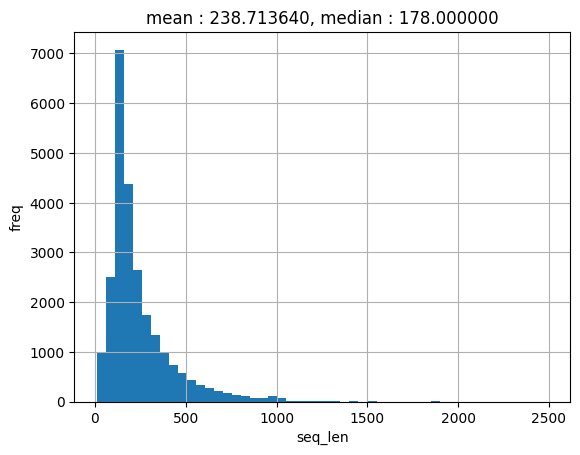

In [11]:
# 각 리뷰의 길이 확인
import matplotlib.pyplot as plt
import numpy as np

X_train_len = [len(seq) for seq in X_train]
plt.hist(X_train_len,bins=50)
plt.xlabel('seq_len')
plt.ylabel('freq')
plt.title(f'mean : {np.mean(X_train_len):2f}, median : {np.median(X_train_len):2f}')
plt.grid()
plt.show()

In [12]:
# 문장 길이 맞추기
from tensorflow.keras.preprocessing.sequence import pad_sequences

X_train = pad_sequences(X_train, maxlen=seq_len, padding = 'post', truncating = 'post')
X_test = pad_sequences(X_test, maxlen=seq_len, padding = 'post', truncating = 'post')

In [13]:
print(X_train[0])

print(X_train.shape,y_train.shape)
print(X_test.shape,y_test.shape)

[  1  14  22  16  43   2   2   2   2  65   2   2  66   2   4 173  36 256
   5  25 100  43   2 112  50   2   2   9  35   2 284   5 150   4 172 112
 167   2   2   2  39   4 172   2   2  17   2  38  13   2   4 192  50  16
   6 147   2  19  14  22   4   2   2   2   4  22  71  87  12  16  43   2
  38  76  15  13   2   4  22  17   2  17  12  16   2  18   2   5  62   2
  12   8   2   8 106   5   4   2   2  16]
(25000, 100) (25000,)
(10000, 100) (10000,)


In [15]:
# one-hot encoding
# X 입력값 (batch_size, seq_len, vocab_size)
from tensorflow.keras.utils import to_categorical

X_train_onehot = to_categorical(X_train,num_classes = vocab_size)
X_test_onehot = to_categorical(X_test,num_classes = vocab_size)
print(X_train_onehot.shape)
print(X_test_onehot.shape)

(25000, 100, 300)
(10000, 100, 300)


In [19]:
# tensor 변환
X_train_onehot = torch.tensor(X_train_onehot,dtype=torch.float)
X_test_onehot = torch.tensor(X_test_onehot,dtype=torch.float)

y_train = torch.tensor(y_train, dtype=torch.float).unsqueeze(1)
y_test = torch.tensor(y_test, dtype=torch.float).unsqueeze(1)

print(X_train_onehot.shape, y_train.shape)
print(X_test_onehot.shape, y_test.shape)

C:\Users\Playdata\AppData\Local\Temp\ipykernel_9336\2363501901.py:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X_train_onehot = torch.tensor(X_train_onehot,dtype=torch.float)
C:\Users\Playdata\AppData\Local\Temp\ipykernel_9336\2363501901.py:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X_test_onehot = torch.tensor(X_test_onehot,dtype=torch.float)


torch.Size([25000, 100, 300]) torch.Size([25000, 1])
torch.Size([10000, 100, 300]) torch.Size([10000, 1])


In [20]:
# RNN 모델 생성
class RNNSentimenticNet(nn.Module):
    def __init__(self,input_size,hidden_size):
        super().__init__()
        """
        Params:
        - input_size : 원핫 인코딩 기준 단어 수
        - hidden_size : RNN 뉴런 수
        """
        self.rnn = nn.RNN(
            input_size,
            hidden_size,
            batch_first=True
        )
        self.fc = nn.Linear(hidden_size,1)

    def forward(self, x):
        _, hidden = self.rnn(x)
        out = self.fc(hidden.squeeze())     # 마지막 시점의 출력 사용
        return out
    
model = RNNSentimenticNet(input_size=vocab_size, hidden_size=8)
print(model)

RNNSentimenticNet(
  (rnn): RNN(300, 8, batch_first=True)
  (fc): Linear(in_features=8, out_features=1, bias=True)
)


In [24]:
# 모델 파라미터 확인
total_params = 0
for name, param in model.named_parameters():
    # print(name,param)
    if param.requires_grad:             # 미분 가능한 파라미터만
        param_count = param.numel()     # 모든 가중치 개수
        total_params += param_count
        print(f'{name:<20} {str(list(param.shape)):<30} {param_count}')

print(f'Total Trainable Parameters : {total_params}')

rnn.weight_ih_l0     [8, 300]                       2400
rnn.weight_hh_l0     [8, 8]                         64
rnn.bias_ih_l0       [8]                            8
rnn.bias_hh_l0       [8]                            8
fc.weight            [1, 8]                         8
fc.bias              [1]                            1
Total Trainable Parameters : 2489


In [25]:
# 학습/검증/평가 데이터 준비
from torch.utils.data import random_split,DataLoader,TensorDataset

batch_size = 64
train_size = int(len(X_train_onehot) * 0.8)
val_size = len(X_train_onehot) - train_size

train_dataset, val_dataset = random_split(TensorDataset(X_train_onehot,y_train),[train_size,val_size])
test_dataset = TensorDataset(X_test_onehot, y_test)

train_dataloader = DataLoader(train_dataset,batch_size=batch_size,shuffle=True)
val_dataloader = DataLoader(val_dataset,batch_size=batch_size,shuffle=False)
test_dataloader = DataLoader(test_dataset,batch_size=batch_size,shuffle=False)

In [27]:
from torch.optim import Adam

# 손실 함수
criterion = nn.BCEWithLogitsLoss()
# 옵티마이저
optimizer = Adam(model.parameters(),lr=0.0001)

epochs = 100

# 시각화를 위한 기록
train_losses, val_losses, train_accs, val_accs = [],[],[],[]

# 조기 종료 관련
early_stopping_paitience = 20
best_val_loss = float('inf')
early_stopping_counter = 0

for epoch in range(epochs):
    total_loss, correct, total = 0,0,0

    # 학습
    model.train()
    for inputs, labels in train_dataloader:
        optimizer.zero_grad()
        output = model(inputs)
        loss = criterion(output,labels)
        loss.backward()
        optimizer.step()

        # 배치 로그
        total_loss += loss.item()
        prob = torch.sigmoid(output)
        pred = (prob >= 0.5).float()
        correct += (pred == labels).sum().item()
        total += labels.size(0)

    # 에폭 로그
    train_loss = total_loss/len(train_dataloader)
    train_losses.append(train_loss)
    train_acc = correct/total
    train_accs.append(train_acc)

    # 검증
    model.eval()
    val_loss, val_correct, val_total = 0,0,0
    with torch.no_grad():
        for val_inputs, val_labels in val_dataloader:
            
            output = model(val_inputs)
            loss = criterion(output, val_labels)
            
            # 배치 로그
            val_loss += loss.item()
            prob = torch.sigmoid(output)
            pred = (prob >= 0.5).float()
            val_correct += (pred == val_labels).sum().item()
            val_total += val_labels.size(0)

        # 에폭 로그
        val_loss = val_loss/len(val_dataloader)
        val_losses.append(val_loss)
        val_acc = val_correct/val_total
        val_accs.append(val_acc)

        print(f'Epoch {epoch+1}/{epochs}: Train Loss : {train_loss:4f}\
              Train acc : {train_acc:4f} Val_loss : {val_loss:4f} Val_acc : {val_acc:4f}')
        
        # 조기 종료
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            early_stopping_counter = 0
        else:
            early_stopping_counter += 1
            if early_stopping_counter >= early_stopping_paitience:
                print(f'Early stopped at epoch {epoch + 1}') 
                break

Epoch 1/100: Train Loss : 0.694770              Train acc : 0.496400 Val_loss : 0.694465 Val_acc : 0.492400
Epoch 2/100: Train Loss : 0.694015              Train acc : 0.497500 Val_loss : 0.694268 Val_acc : 0.485400
Epoch 3/100: Train Loss : 0.693623              Train acc : 0.500400 Val_loss : 0.693995 Val_acc : 0.485200
Epoch 4/100: Train Loss : 0.693306              Train acc : 0.502300 Val_loss : 0.693793 Val_acc : 0.488000
Epoch 5/100: Train Loss : 0.693058              Train acc : 0.504500 Val_loss : 0.693595 Val_acc : 0.487600
Epoch 6/100: Train Loss : 0.692804              Train acc : 0.506850 Val_loss : 0.693354 Val_acc : 0.488800
Epoch 7/100: Train Loss : 0.692561              Train acc : 0.516500 Val_loss : 0.693203 Val_acc : 0.504200
Epoch 8/100: Train Loss : 0.692331              Train acc : 0.518250 Val_loss : 0.692909 Val_acc : 0.507400
Epoch 9/100: Train Loss : 0.692088              Train acc : 0.520850 Val_loss : 0.692682 Val_acc : 0.506400
Epoch 10/100: Train Loss : 0

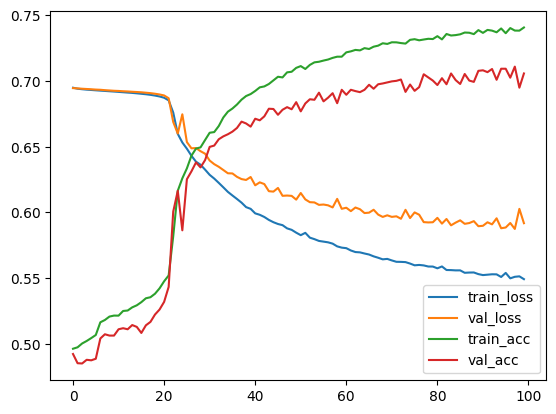

In [28]:
# 시각화
import pandas as pd
import matplotlib.pyplot as plt

df = pd.DataFrame({
    'train_loss':train_losses,
    'val_loss':val_losses,
    'train_acc':train_accs,
    'val_acc':val_accs
})

df.plot()
plt.show()

In [29]:
# 평가
def evaluate_model(model, test_dataloader, criterion):
    model.eval()
    test_loss, test_correct,test_total = 0,0,0
    with torch.no_grad():
        for test_inputs,test_labels, in test_dataloader:
            output = model(test_inputs)
            loss = criterion(output,test_labels)

            test_loss += loss.item()
            prob = torch.sigmoid(output)
            pred = (prob >= 0.5).float()
            test_correct += (pred == test_labels).sum().item()
            test_total += test_labels.size(0)

    test_loss = test_loss/len(test_dataloader)
    test_acc = test_correct/test_total

    return test_loss,test_acc

test_dataset = TensorDataset(X_test_onehot,y_test)
test_dataloader = DataLoader(test_dataset,batch_size=batch_size,shuffle=True)

test_loss, test_acc = evaluate_model(model, test_dataloader,criterion)
print(f'Test loss: {test_loss}, Test_acc: {test_acc}')

Test loss: 0.5807340306461237, Test_acc: 0.7108
